# Hate Speech Analysis

This is the final submission notebook for the hate-speech detection project. It presents the clean exploratory analysis, the preprocessing pipeline, and the final tuned `LinearSVC` model used for the project.

In [2]:
from pathlib import Path
import pickle
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

from src.preprocess import LABEL_MAP, build_clean_dataframe, clean_text, load_raw_dataset

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

In [3]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
VECTORIZER_PATH = MODELS_DIR / "tfidf_vectorizer.pkl"
MODEL_PATH = MODELS_DIR / "hate_speech_svc.pkl"

df_raw = load_raw_dataset()
df = build_clean_dataframe(df_raw)

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Dataset shape: (24783, 7)
Columns: ['count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet', 'clean_tweet']


,count,hate_speech,offensive_language,neither,class,tweet,clean_tweet
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...,as a woman you shouldn t complain about cleaning up your house amp as a man you should always take the trash out
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!,boy dats cold tyga dwn bad for cuffin dat hoe in the st place
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit,dawg you ever fuck a bitch and she start to cry you be confused as shit
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny,she look like a tranny
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you hear about me might be true or it might be faker than the bitch who told it to ya &#57361;,the shit you hear about me might be true or it might be faker than the bitch who told it to ya


## 1. Clean EDA

The dataset is strongly imbalanced, so minority-class performance, especially the `hate_speech` class, matters more than raw accuracy.

In [4]:
class_counts = df["class"].value_counts().sort_index()
class_df = pd.DataFrame({
    "class": class_counts.index,
    "label": [LABEL_MAP.get(i, str(i)) for i in class_counts.index],
    "count": class_counts.values,
    "percent": (class_counts.values / len(df) * 100).round(2),
})
class_df

,class,label,count,percent
0,0,hate_speech,1430,5.77
1,1,offensive_language,19190,77.43
2,2,neither,4163,16.80


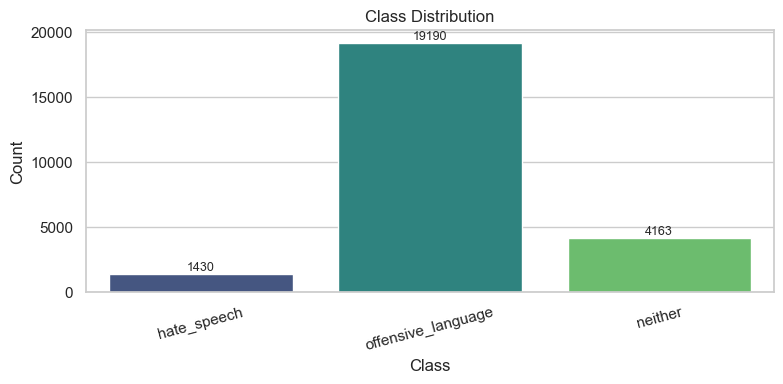

In [5]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=class_df, x="label", y="count", hue="label", dodge=False, legend=False, palette="viridis")
ax.set_title("Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
for i, count in enumerate(class_df["count"]):
    ax.text(i, count, str(count), ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [6]:
df["char_len"] = df["tweet"].astype(str).str.len()
df["word_len"] = df["tweet"].astype(str).str.split().str.len()
df[["char_len", "word_len"]].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

,char_len,word_len
count,24783.000000,24783.000000
mean,85.436065,14.117016
std,41.548238,6.825525
min,5.000000,1.000000
10%,34.000000,6.000000
25%,52.000000,9.000000
50%,81.000000,13.000000
75%,119.000000,19.000000
90%,140.000000,24.000000
99%,174.000000,29.000000


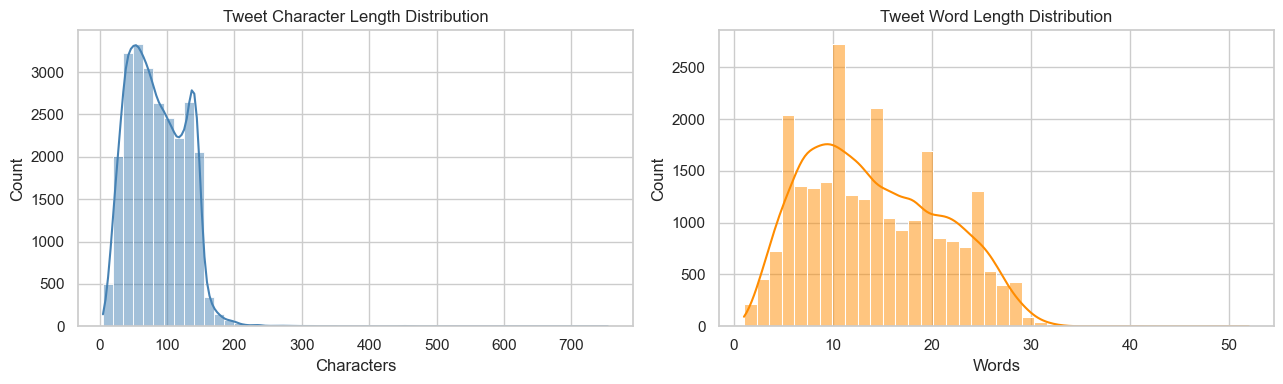

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["char_len"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Tweet Character Length Distribution")
axes[0].set_xlabel("Characters")
sns.histplot(df["word_len"], bins=40, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Tweet Word Length Distribution")
axes[1].set_xlabel("Words")
plt.tight_layout()
plt.show()

C:\Users\Atharva\AppData\Local\Temp\ipykernel_26800\3699266332.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y="char_len", ax=axes[0], palette="Set2")
C:\Users\Atharva\AppData\Local\Temp\ipykernel_26800\3699266332.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y="word_len", ax=axes[1], palette="Set3")


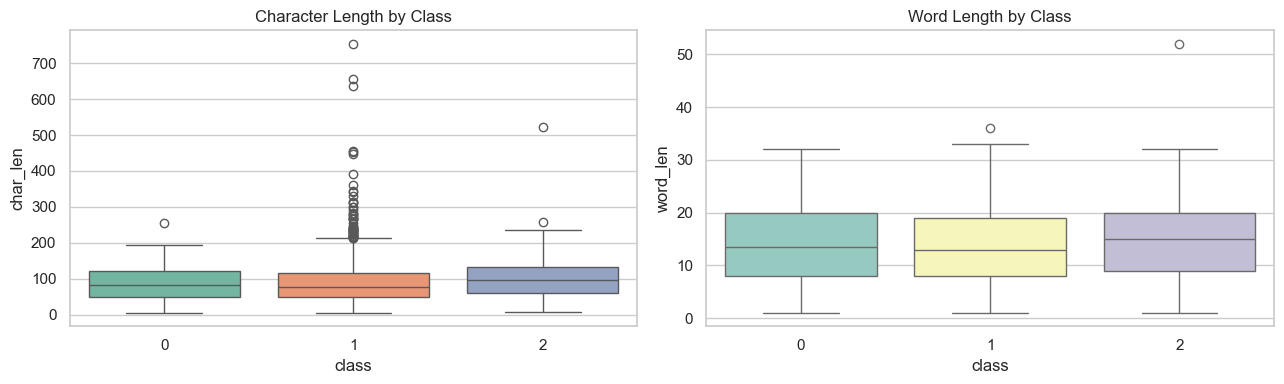

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x="class", y="char_len", ax=axes[0], palette="Set2")
axes[0].set_title("Character Length by Class")
sns.boxplot(data=df, x="class", y="word_len", ax=axes[1], palette="Set3")
axes[1].set_title("Word Length by Class")
plt.tight_layout()
plt.show()

In [9]:
URL_RE = re.compile(r"https?://\\S+|www\\.\\S+", re.IGNORECASE)
MENTION_RE = re.compile(r"@\\w+")
HASHTAG_RE = re.compile(r"#\\w+")
RT_RE = re.compile(r"\\bRT\\b", re.IGNORECASE)

pattern_df = df.copy()
pattern_df["has_url"] = pattern_df["tweet"].astype(str).str.contains(URL_RE)
pattern_df["has_mention"] = pattern_df["tweet"].astype(str).str.contains(MENTION_RE)
pattern_df["has_hashtag"] = pattern_df["tweet"].astype(str).str.contains(HASHTAG_RE)
pattern_df["has_rt"] = pattern_df["tweet"].astype(str).str.contains(RT_RE)

pattern_summary = pd.DataFrame({
    "feature": ["has_url", "has_mention", "has_hashtag", "has_rt"],
    "count": [
        int(pattern_df["has_url"].sum()),
        int(pattern_df["has_mention"].sum()),
        int(pattern_df["has_hashtag"].sum()),
        int(pattern_df["has_rt"].sum()),
    ],
})
pattern_summary["percent"] = (pattern_summary["count"] / len(pattern_df) * 100).round(2)
pattern_summary

,feature,count,percent
0,has_url,0,0.0
1,has_mention,0,0.0
2,has_hashtag,0,0.0
3,has_rt,0,0.0


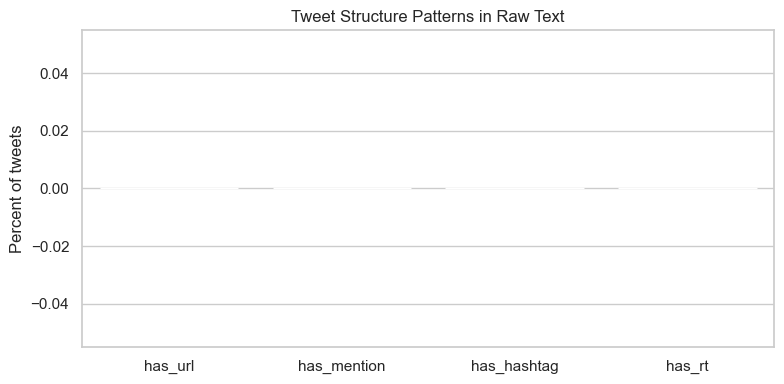

In [10]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=pattern_summary, x="feature", y="percent", hue="feature", dodge=False, legend=False, palette="magma")
ax.set_title("Tweet Structure Patterns in Raw Text")
ax.set_ylabel("Percent of tweets")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [11]:
def top_ngrams(corpus, ngram_range=(1, 1), top_k=12, min_df=2):
    vectorizer = CountVectorizer(stop_words="english", ngram_range=ngram_range, min_df=min_df)
    matrix = vectorizer.fit_transform(corpus)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    top_idx = counts.argsort()[::-1][:top_k]
    return pd.DataFrame({"term": terms[top_idx], "count": counts[top_idx]})

class_term_tables = []
for class_id in sorted(df["class"].unique()):
    subset = df.loc[df["class"] == class_id, "clean_tweet"]
    top_terms = top_ngrams(subset, ngram_range=(1, 1), top_k=10, min_df=2)
    top_terms.insert(0, "label", LABEL_MAP[class_id])
    class_term_tables.append(top_terms)

pd.concat(class_term_tables, ignore_index=True)

,label,term,count
0,hate_speech,bitch,209
1,hate_speech,faggot,191
2,hate_speech,like,169
3,hate_speech,nigga,140
4,hate_speech,ass,138
5,hate_speech,white,127
6,hate_speech,fuck,121
7,hate_speech,trash,113
8,hate_speech,nigger,112
9,hate_speech,fucking,95


## 2. Preprocessing Pipeline

The final text pipeline removes URLs, mentions, the `RT` token, punctuation and non-letter symbols, then lowercases and compresses repeated whitespace before TF-IDF vectorization.

In [12]:
sample_rows = df[["tweet", "clean_tweet"]].head(5).copy()
sample_rows

,tweet,clean_tweet
0,!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...,as a woman you shouldn t complain about cleaning up your house amp as a man you should always take the trash out
1,!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!,boy dats cold tyga dwn bad for cuffin dat hoe in the st place
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit,dawg you ever fuck a bitch and she start to cry you be confused as shit
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny,she look like a tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you hear about me might be true or it might be faker than the bitch who told it to ya &#57361;,the shit you hear about me might be true or it might be faker than the bitch who told it to ya


In [13]:
vectorizer = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
)
vectorizer

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",False
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(

## Tuned LinearSVC

Because the dataset is imbalanced, the final model uses `class_weight='balanced'`. The key result to watch is the `Class 0` F1-score because class `0` corresponds to `hate_speech`.

In [14]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_tweet"],
    df["class"],
    test_size=0.2,
    random_state=42,
    stratify=df["class"],
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

svc = LinearSVC(
    C=0.5,
    class_weight="balanced",
    loss="hinge",
    max_iter=15000,
    random_state=42,
)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

print("Train matrix:", X_train.shape)
print("Test matrix:", X_test.shape)

Train matrix: (19826, 20000)
Test matrix: (4957, 20000)


In [15]:
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    "class0_precision": report_dict["0"]["precision"],
    "class0_recall": report_dict["0"]["recall"],
    "class0_f1": report_dict["0"]["f1-score"],
}
pd.DataFrame([metrics]).round(4)

,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,class0_precision,class0_recall,class0_f1
0,0.8947,0.7359,0.767,0.7493,0.8955,0.4621,0.4476,0.4547


In [16]:
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

              precision    recall  f1-score   support

           0     0.4621    0.4476    0.4547       286
           1     0.9548    0.9195    0.9368      3838
           2     0.7907    0.9340    0.8564       833

    accuracy                         0.8947      4957
   macro avg     0.7359    0.7670    0.7493      4957
weighted avg     0.8988    0.8947    0.8955      4957



In [17]:
class0_summary = pd.DataFrame([
    {
        "focus_metric": "Class 0 (hate_speech) F1-score",
        "value": report_dict["0"]["f1-score"],
    },
    {
        "focus_metric": "Class 0 (hate_speech) Recall",
        "value": report_dict["0"]["recall"],
    },
    {
        "focus_metric": "Macro F1",
        "value": f1_score(y_test, y_pred, average="macro", zero_division=0),
    },
])
class0_summary.round(4)

,focus_metric,value
0,Class 0 (hate_speech) F1-score,0.4547
1,Class 0 (hate_speech) Recall,0.4476
2,Macro F1,0.7493


In [18]:
labels = sorted(df["class"].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"true_{i}" for i in labels], columns=[f"pred_{i}" for i in labels])
cm_df

,pred_0,pred_1,pred_2
true_0,128,123,35
true_1,138,3529,171
true_2,11,44,778


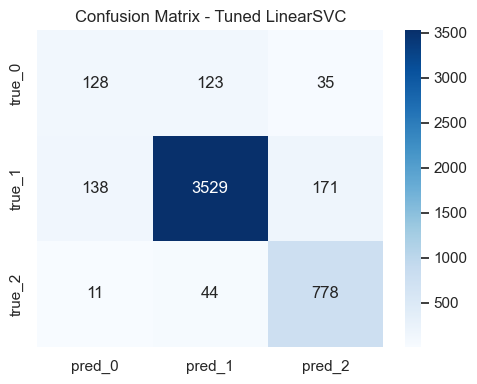

In [19]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Tuned LinearSVC")
plt.tight_layout()
plt.show()

In [20]:
with VECTORIZER_PATH.open("wb") as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)
with MODEL_PATH.open("wb") as model_file:
    pickle.dump(svc, model_file)
print(f"Saved vectorizer to {VECTORIZER_PATH}")
print(f"Saved model to {MODEL_PATH}")

Saved vectorizer to C:\Users\Atharva\OneDrive\Desktop\WebD\hate-speech-detection\models\tfidf_vectorizer.pkl
Saved model to C:\Users\Atharva\OneDrive\Desktop\WebD\hate-speech-detection\models\hate_speech_svc.pkl


## 4. Ablation Summary

The classical `LinearSVC` was selected as the final model because it gave the best trade-off between macro F1 and minority-class detection. The TF-IDF representation is very strong for short, noisy tweets, and the linear margin-based model handled the sparse feature space efficiently.

The deep learning attempts were useful experiments, but they did not beat the final SVC on the core evaluation goal. The MLP needed dimensionality reduction to remain stable on sparse TF-IDF inputs, and the embedding-based CNN required more tuning and data efficiency than this project setting allowed. In practice, the tuned SVC remained the most reliable model for improving the `hate_speech` class F1-score while keeping the training pipeline simple and reproducible.